In [20]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report
from tensorflow.keras.datasets import cifar10

# Carregamento dos dados
## CIFAR-10: 60.000 imagens coloridas (32x32x3), 10 classes
- x_train: imagens de treino
- y_train: rótulos do treino (inteiros 0..9)
- x_test: imagens de teste
- y_test: rótulos de teste

In [21]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

## Remover uma dimensão redundante de y

In [22]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

## Confere os shapes

In [23]:
print("Shapes")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

Shapes
x_train: (50000, 32, 32, 3) y_train: (50000,)
x_test: (10000, 32, 32, 3) y_test: (10000,)


## Visualização

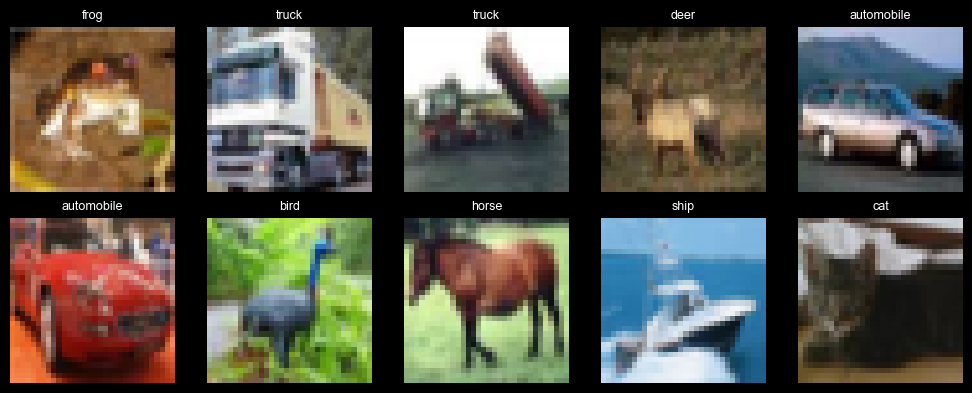

In [24]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]], fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()

# Pré-processamento

In [25]:
x_train = x_train.astype("float32") / 255.0
y_test = x_test.astype("float32") / 255.0


## Conferência

In [26]:
print("Intervalo dos pixels (treino): ", x_train.min(), "a", x_train.max())

Intervalo dos pixels (treino):  0.0 a 0.003921569


## Definição do nosso modelo CNN

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(32,32,3)),
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 32, 32, 32)        896       
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 16, 16, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_3 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 8, 8, 64)          0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 4096)              0         
                                                                 
 dense_2 (Dense)             (None, 128)              

## Compilação do Modelo

In [28]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

## Treinamento

In [29]:
history = model.fit(
    x_train,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
352/352 - 30s - loss: 2.1041 - accuracy: 0.2316 - val_loss: 1.9934 - val_accuracy: 0.2810 - 30s/epoch - 86ms/step
Epoch 2/10
352/352 - 30s - loss: 1.9208 - accuracy: 0.3140 - val_loss: 1.8740 - val_accuracy: 0.3166 - 30s/epoch - 85ms/step
Epoch 3/10
352/352 - 33s - loss: 1.8236 - accuracy: 0.3442 - val_loss: 1.8034 - val_accuracy: 0.3522 - 33s/epoch - 93ms/step
Epoch 4/10
352/352 - 29s - loss: 1.7280 - accuracy: 0.3821 - val_loss: 1.6970 - val_accuracy: 0.3936 - 29s/epoch - 83ms/step
Epoch 5/10
352/352 - 31s - loss: 1.6534 - accuracy: 0.4114 - val_loss: 1.6316 - val_accuracy: 0.4202 - 31s/epoch - 88ms/step
Epoch 6/10
352/352 - 28s - loss: 1.6008 - accuracy: 0.4320 - val_loss: 1.5836 - val_accuracy: 0.4350 - 28s/epoch - 81ms/step
Epoch 7/10
352/352 - 29s - loss: 1.5631 - accuracy: 0.4461 - val_loss: 1.5534 - val_accuracy: 0.4498 - 29s/epoch - 81ms/step
Epoch 8/10
352/352 - 30s - loss: 1.5313 - accuracy: 0.4572 - val_loss: 1.5570 - val_accuracy: 0.4534 - 30s/epoch - 84ms/step


## Curvas

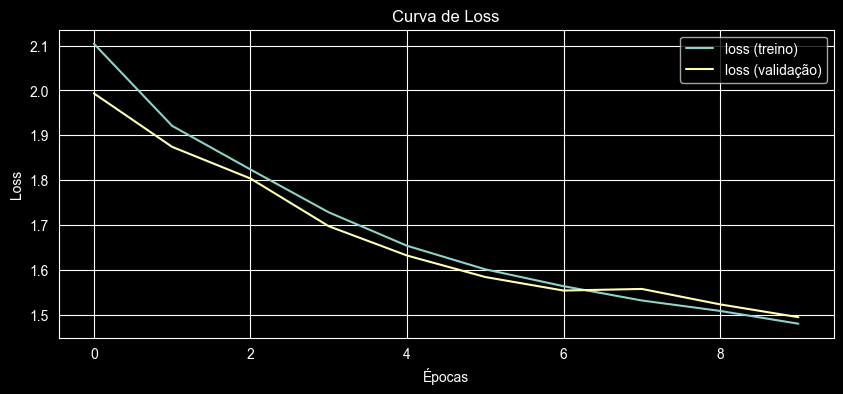

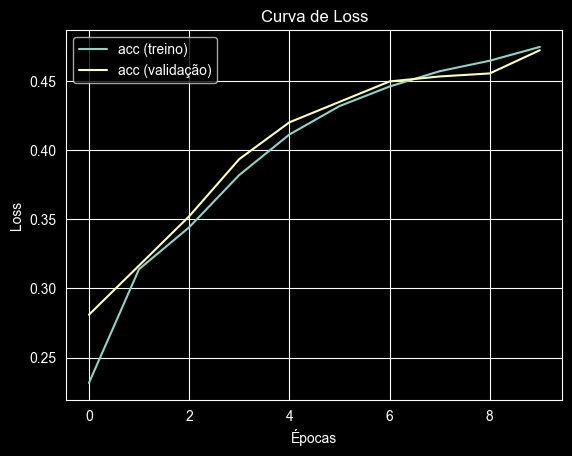

In [30]:
plt.figure(figsize=(10, 4))

plt.plot(history.history["loss"], label = "loss (treino)")
plt.plot(history.history["val_loss"], label = "loss (validação)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.legend()
plt.show()

plt.plot(history.history["accuracy"], label = "acc (treino)")
plt.plot(history.history["val_accuracy"], label = "acc (validação)")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Curva de Loss")
plt.legend()
plt.show()

## Avaliação do Conjunto de Teste

In [31]:
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

print("Menor classe:", y_test.min())
print("Maior classe:", y_test.max())

print("Saída do modelo:", model.output_shape)

x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 32, 32, 3)
Menor classe: 0.0
Maior classe: 0.003921569
Saída do modelo: (None, 10)


In [32]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f" Teste - Loss: {test_loss:.4f} | accuracy: {test_acc:.4f}")

InvalidArgumentError: Graph execution error:

Detected at node 'sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits' defined at (most recent call last):
    File "C:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "C:\Users\Usuario\AppData\Local\Programs\Python\Python310\lib\runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "C:\Users\Usuario\workspace\visao_computacional\mnist\.venv\lib\site-packages\ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "C:\Users\Usuario\workspace\visao_computacional\mnist\.venv\lib\site-packages\traitlets\config\application.py", line 1082, in launch_instance
      app.start()
    File "C:\Users\Usuario\workspace\visao_computacional\mnist\.venv\lib\site-packages\ipykernel\kernelapp.py", line 739, in start
      self.io_loop.start()
    Fi

## Predição detalhada

In [33]:
y_prob = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_prob, axis= 1)

print(classification_report(y_test, y_pred, target_names=class_names))

ValueError: Classification metrics can't handle a mix of unknown and multiclass targets